# 1. Impoved Model

## 1.1 Improved MNIST Model

### Hyperparameters for Improved Model

In [1]:
# Hyperparameters
learning_rate = 0.001
num_epochs = 100
batch_size = 64 # Changed from 50 to a more common power-of-2 batch size

# Leaky ReLU parameter
leaky_relu_negative_slope = 0.01

# Model specific parameters
mnist_input_channels = 1
mnist_num_classes = 10

# Convolutional Layer 1
conv1_out_channels = 16
conv1_kernel_size = 5
conv1_stride = 2
conv1_padding = 0 # To match vanilla output size for first conv

# Pooling Layer 1
pool1_kernel_size = 2
pool1_stride = 2

# Convolutional Layer 2
conv2_out_channels = 32
conv2_kernel_size = 3
conv2_stride = 1
conv2_padding = 1 # To maintain spatial dimensions before second pooling

# Pooling Layer 2
pool2_kernel_size = 2
pool2_stride = 2

### Data Loading and Preparation (MNIST)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score
import seaborn as sns
import os # Import os module for num_workers

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard MNIST normalization
])

# MNIST Dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split training data into training and validation sets
train_data, val_data = random_split(train_dataset, [50000, 10000])

# Data loaders
num_workers = os.cpu_count() // 2 if os.cpu_count() > 1 else 0 # Use half of CPU cores for data loading
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_dataset)}")

Using device: cpu
Training set size: 50000
Validation set size: 10000
Test set size: 10000


### Model Definition (Improved CNN)

This model uses a standard CNN architecture with two convolutional layers, each followed by batch normalization, ReLU activation, and max pooling. Finally, a fully connected layer maps the features to the 10 output classes. The parameters for the first convolutional and pooling layers are chosen to roughly match the spatial dimension reduction of the vanilla model's custom implementation, while adding depth and optimizations for accuracy.

In [3]:
class ImprovedCNN(nn.Module):
    def __init__(self, in_channels, num_classes, conv1_out_channels, conv1_kernel_size, conv1_stride, conv1_padding,
                 pool1_kernel_size, pool1_stride, conv2_out_channels, conv2_kernel_size, conv2_stride, conv2_padding,
                 pool2_kernel_size, pool2_stride, dropout_rate=0.5, leaky_relu_negative_slope=0.01):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, conv1_out_channels, kernel_size=conv1_kernel_size, stride=conv1_stride, padding=conv1_padding)
        self.bn1 = nn.BatchNorm2d(conv1_out_channels)
        self.pool1 = nn.MaxPool2d(kernel_size=pool1_kernel_size, stride=pool1_stride)

        self.conv2 = nn.Conv2d(conv1_out_channels, conv2_out_channels, kernel_size=conv2_kernel_size, stride=conv2_stride, padding=conv2_padding)
        self.bn2 = nn.BatchNorm2d(conv2_out_channels)
        self.pool2 = nn.MaxPool2d(kernel_size=pool2_kernel_size, stride=pool2_stride)

        self.dropout = nn.Dropout(dropout_rate)
        self.leaky_relu_negative_slope = leaky_relu_negative_slope

        # Calculate flattened size dynamically
        # Dummy tensor to calculate output size after convolutions and pooling
        self._to_linear = None
        self.calc_linear_input_size(in_channels, (28, 28)) # Assuming 28x28 for MNIST, Fashion-MNIST, K-MNIST

        self.fc = nn.Linear(self._to_linear, num_classes)

    def calc_linear_input_size(self, in_channels, input_shape):
        x = torch.zeros(1, in_channels, input_shape[0], input_shape[1])
        x = self.pool1(F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=self.leaky_relu_negative_slope))
        x = self.pool2(F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=self.leaky_relu_negative_slope))
        self._to_linear = x.numel() // x.shape[0]

    def forward(self, x):
        x = self.pool1(F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=self.leaky_relu_negative_slope))
        x = self.pool2(F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=self.leaky_relu_negative_slope))
        x = x.view(-1, self._to_linear) # Flatten the tensor
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Adjust for CIFAR10 (32x32) later
class ImprovedCNN_CIFAR(ImprovedCNN):
    def calc_linear_input_size(self, in_channels, input_shape):
        x = torch.zeros(1, in_channels, input_shape[0], input_shape[1])
        x = self.pool1(F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=self.leaky_relu_negative_slope))
        x = self.pool2(F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=self.leaky_relu_negative_slope))
        self._to_linear = x.numel() // x.shape[0]


### Training and Evaluation Functions

These generic functions will be used for all datasets.

In [4]:
def save_checkpoint(model, optimizer, epoch, val_acc, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_accuracy': val_acc
    }, path)

    print(f" Saved checkpoint: {path}")
    
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, model_name="Model"):
    model.train()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0.0

    print(f"\n--- Training {model_name} ---")

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        model.train()

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(
                model,
                optimizer,
                epoch,
                val_acc,
                path=f"./checkpoints/{model_name}_best.pth"
            )

    print(f"--- Training of {model_name} finished ---")

    return train_losses, val_losses, train_accuracies, val_accuracies

def evaluate_model(model, test_loader, device, num_classes, model_name="Model"):
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    print(f"\n--- Evaluation for {model_name} ---")
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    return accuracy, precision, recall, f1, cm

def plot_loss_curves(train_losses, val_losses, train_accuracies, val_accuracies, model_name="Model"):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


### Training and Evaluation (MNIST)


--- Training MNIST Model ---
Epoch [1/100], Train Loss: 0.4124, Train Acc: 87.30%, Val Loss: 0.0987, Val Acc: 97.23%
Epoch [2/100], Train Loss: 0.1523, Train Acc: 95.39%, Val Loss: 0.0762, Val Acc: 97.61%
Epoch [3/100], Train Loss: 0.1244, Train Acc: 96.16%, Val Loss: 0.0603, Val Acc: 98.33%
Epoch [4/100], Train Loss: 0.1078, Train Acc: 96.63%, Val Loss: 0.0557, Val Acc: 98.32%
Epoch [5/100], Train Loss: 0.0941, Train Acc: 97.12%, Val Loss: 0.0484, Val Acc: 98.60%
Epoch [6/100], Train Loss: 0.0896, Train Acc: 97.19%, Val Loss: 0.0482, Val Acc: 98.56%
Epoch [7/100], Train Loss: 0.0838, Train Acc: 97.36%, Val Loss: 0.0479, Val Acc: 98.57%
Epoch [8/100], Train Loss: 0.0779, Train Acc: 97.50%, Val Loss: 0.0445, Val Acc: 98.70%
Epoch [9/100], Train Loss: 0.0725, Train Acc: 97.67%, Val Loss: 0.0419, Val Acc: 98.71%
Epoch [10/100], Train Loss: 0.0701, Train Acc: 97.78%, Val Loss: 0.0416, Val Acc: 98.71%
Epoch [11/100], Train Loss: 0.0680, Train Acc: 97.85%, Val Loss: 0.0412, Val Acc: 98.82%


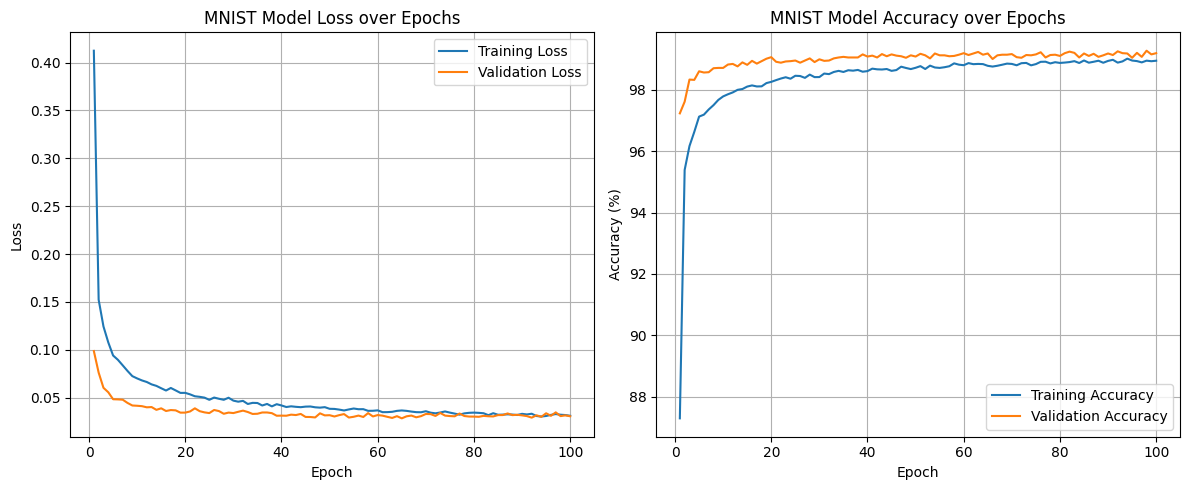


--- Evaluation for MNIST Model ---
Accuracy: 0.9911
Precision: 0.9910
Recall: 0.9910
F1 Score: 0.9910


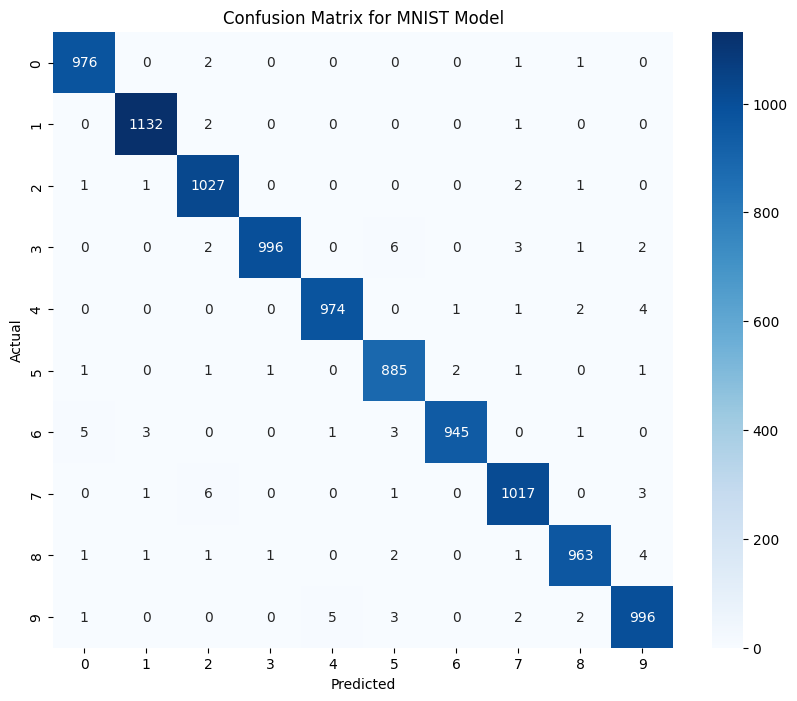

In [8]:
# Model, Optimizer, Loss for MNIST
mnist_model = ImprovedCNN(mnist_input_channels, mnist_num_classes,
                          conv1_out_channels, conv1_kernel_size, conv1_stride, conv1_padding,
                          pool1_kernel_size, pool1_stride, conv2_out_channels, conv2_kernel_size, conv2_stride, conv2_padding,
                          pool2_kernel_size, pool2_stride, leaky_relu_negative_slope=leaky_relu_negative_slope).to(device)

mnist_criterion = nn.CrossEntropyLoss()
mnist_optimizer = optim.Adam(mnist_model.parameters(), lr=learning_rate)

# Train MNIST model
mnist_train_losses, mnist_val_losses, mnist_train_accuracies, mnist_val_accuracies = train_model(
    mnist_model, train_loader, val_loader, mnist_criterion, mnist_optimizer, num_epochs, device, model_name="MNIST Model")

# Plot loss and accuracy curves
plot_loss_curves(mnist_train_losses, mnist_val_losses, mnist_train_accuracies, mnist_val_accuracies, model_name="MNIST Model")

# Evaluate MNIST model
mnist_accuracy, mnist_precision, mnist_recall, mnist_f1, mnist_cm = evaluate_model(
    mnist_model, test_loader, device, mnist_num_classes, model_name="MNIST Model")

## 1.2 Fashion-MNIST Model

### Hyperparameters for Fashion-MNIST

In [9]:
# Model specific parameters for Fashion-MNIST
fashion_mnist_input_channels = 1
fashion_mnist_num_classes = 10

### Data Loading and Preparation (Fashion-MNIST)

In [10]:
# Fashion-MNIST Dataset
fashion_train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
fashion_test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Split training data into training and validation sets
fashion_train_data, fashion_val_data = random_split(fashion_train_dataset, [50000, 10000])

# Data loaders
num_workers = os.cpu_count() // 2 if os.cpu_count() > 1 else 0
fashion_train_loader = DataLoader(fashion_train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
fashion_val_loader = DataLoader(fashion_val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
fashion_test_loader = DataLoader(fashion_test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Fashion-MNIST Training set size: {len(fashion_train_data)}")
print(f"Fashion-MNIST Validation set size: {len(fashion_val_data)}")
print(f"Fashion-MNIST Test set size: {len(fashion_test_dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.1MB/s]

Fashion-MNIST Training set size: 50000
Fashion-MNIST Validation set size: 10000
Fashion-MNIST Test set size: 10000


### Training and Evaluation (Fashion-MNIST)


--- Training Fashion-MNIST Model ---
Epoch [1/100], Train Loss: 0.6945, Train Acc: 75.01%, Val Loss: 0.4599, Val Acc: 83.22%
Epoch [2/100], Train Loss: 0.5030, Train Acc: 81.70%, Val Loss: 0.4107, Val Acc: 84.74%
Epoch [3/100], Train Loss: 0.4623, Train Acc: 83.31%, Val Loss: 0.3873, Val Acc: 85.49%
Epoch [4/100], Train Loss: 0.4344, Train Acc: 84.17%, Val Loss: 0.3760, Val Acc: 85.98%
Epoch [5/100], Train Loss: 0.4144, Train Acc: 84.82%, Val Loss: 0.3555, Val Acc: 86.93%
Epoch [6/100], Train Loss: 0.4036, Train Acc: 85.42%, Val Loss: 0.3492, Val Acc: 87.06%
Epoch [7/100], Train Loss: 0.3962, Train Acc: 85.42%, Val Loss: 0.3433, Val Acc: 87.22%
Epoch [8/100], Train Loss: 0.3849, Train Acc: 86.14%, Val Loss: 0.3359, Val Acc: 87.64%
Epoch [9/100], Train Loss: 0.3774, Train Acc: 86.26%, Val Loss: 0.3262, Val Acc: 87.99%
Epoch [10/100], Train Loss: 0.3724, Train Acc: 86.37%, Val Loss: 0.3279, Val Acc: 87.79%
Epoch [11/100], Train Loss: 0.3638, Train Acc: 86.83%, Val Loss: 0.3202, Val Acc:

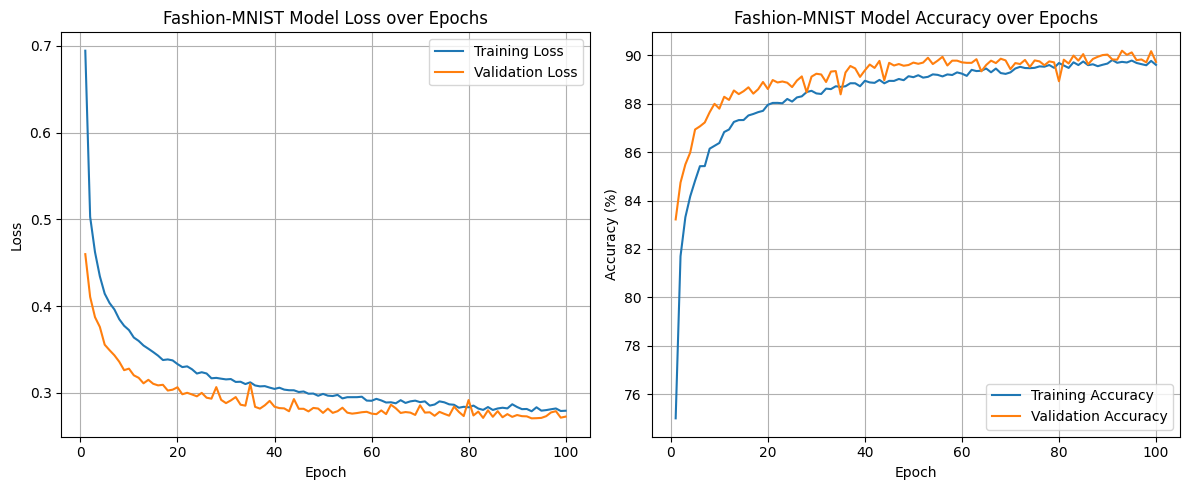


--- Evaluation for Fashion-MNIST Model ---
Accuracy: 0.8953
Precision: 0.8948
Recall: 0.8953
F1 Score: 0.8947


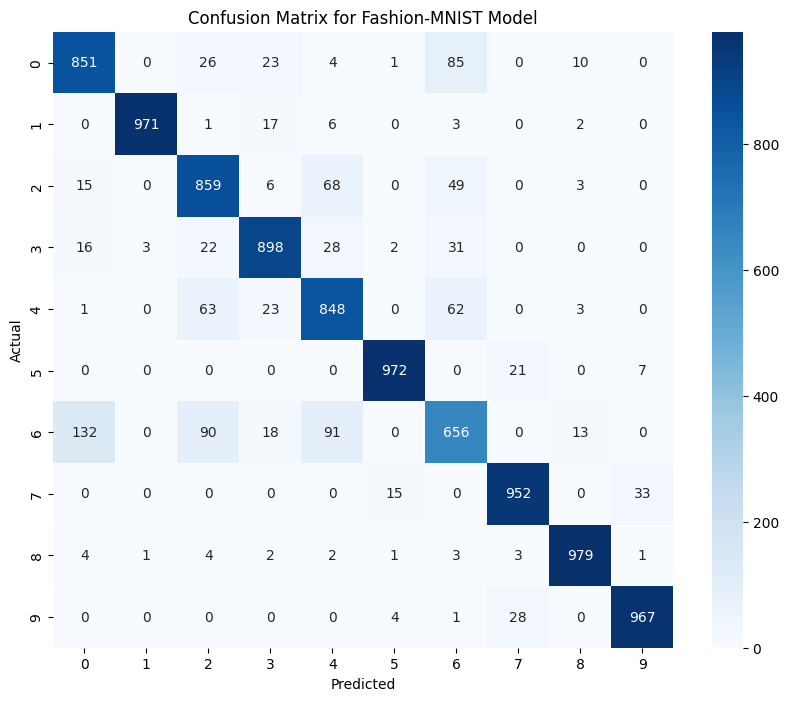

In [11]:
# Model, Optimizer, Loss for Fashion-MNIST (using the same architecture as MNIST)
fashion_mnist_model = ImprovedCNN(fashion_mnist_input_channels, fashion_mnist_num_classes,
                                    conv1_out_channels, conv1_kernel_size, conv1_stride, conv1_padding,
                                    pool1_kernel_size, pool1_stride, conv2_out_channels, conv2_kernel_size, conv2_stride, conv2_padding,
                                    pool2_kernel_size, pool2_stride, leaky_relu_negative_slope=leaky_relu_negative_slope).to(device)

fashion_mnist_criterion = nn.CrossEntropyLoss()
fashion_mnist_optimizer = optim.Adam(fashion_mnist_model.parameters(), lr=learning_rate)

# Train Fashion-MNIST model
fashion_mnist_train_losses, fashion_mnist_val_losses, fashion_mnist_train_accuracies, fashion_mnist_val_accuracies = train_model(
    fashion_mnist_model, fashion_train_loader, fashion_val_loader, fashion_mnist_criterion, fashion_mnist_optimizer, num_epochs, device, model_name="Fashion-MNIST Model")

# Plot loss and accuracy curves
plot_loss_curves(fashion_mnist_train_losses, fashion_mnist_val_losses, fashion_mnist_train_accuracies, fashion_mnist_val_accuracies, model_name="Fashion-MNIST Model")

# Evaluate Fashion-MNIST model
fashion_mnist_accuracy, fashion_mnist_precision, fashion_mnist_recall, fashion_mnist_f1, fashion_mnist_cm = evaluate_model(
    fashion_mnist_model, fashion_test_loader, device, fashion_mnist_num_classes, model_name="Fashion-MNIST Model")

# 2. vanilla from scratch model

# 2.1 Data Loading dan preparation

Using device: cpu
Ukuran training set : 50000x2x1x28x28
Ukuran validation set : 10000x2x1x28x28
Ukuran testing set : 10000x2x1x28x28


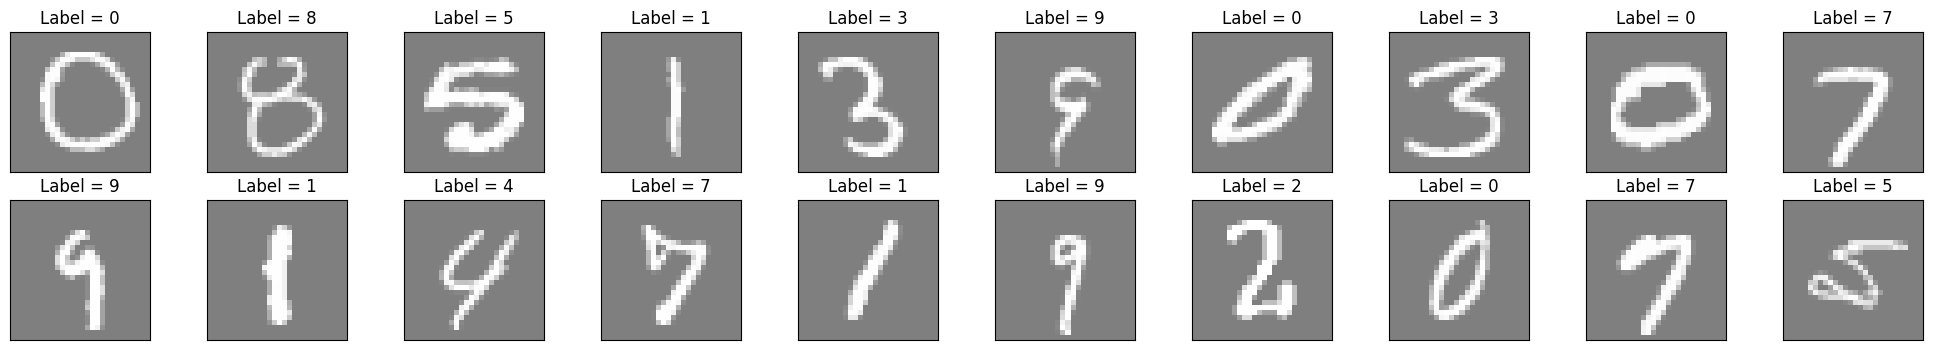

In [5]:
# Memuat semua library yang dibutuhkan untuk proses training dan testing model
# pada MNIST Handwritten Digits Dataset
import torch
import torch.nn as nn
import torch.nn.functional as func
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import random_split
# Pengaturan untuk menentukan device komputasi yang akan digunakan
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Mengunduh dataset (Images & Labels) dan memasukkannya ke dalam variable
train_dataset = datasets.MNIST(root ='./data', train = True,
                               transform = transforms.ToTensor(),
                               download = True)
train_data, val_data = random_split(train_dataset, [50000, 10000])
test_data = datasets.MNIST(root ='./data', train = False,
                              transform = transforms.ToTensor(), download = True)

# Mengecek ukuran dari setiap kelompok data
print("Ukuran training set : {}x{}x{}x{}x{}".format(len(train_data), len(train_data[0]),
                                                    len(train_data[0][0]), len(train_data[0][0][0]),
                                                    len(train_data[0][0][0][0])))
print("Ukuran validation set : {}x{}x{}x{}x{}".format(len(val_data), len(val_data[0]),
                                                      len(val_data[0][0]), len(val_data[0][0][0]),
                                                      len(val_data[0][0][0][0])))
print("Ukuran testing set : {}x{}x{}x{}x{}".format(len(test_data), len(test_data[0]),
                                                   len(test_data[0][0]), len(test_data[0][0][0]),
                                                   len(test_data[0][0][0][0])))
# Catatan:
# - Dimensi ke-0 = Banyaknya data
# - Dimensi ke-1 = Images[1x28x28] + Labels[1]
# Data constants
input_size = 28 * 28
num_classes = 10
# Hyperparameters
batch_size = 50
# Data loaders
train_loader = DataLoader(train_data, batch_size, shuffle=True)
val_loader = DataLoader(val_data, len(val_data), shuffle=False)
test_loader = DataLoader(test_data, len(test_data), shuffle=False)

# Pembuatan fungsi untuk melakukan konversi images dari [-1, 1] ke [0, 1]
# untuk kebutuhan visualisasi
def img_convert(input_tensor):
  image = input_tensor.cpu().clone().detach().numpy()
  # Merubah dari (C,H,W) menjadi (H,W,C)
  image = image.transpose(1, 2, 0)
  # Merubah dari (28,28,1) menjadi (28,28,3) sekaligus mengubah rentang nilai ke [0,1]
  image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5))
  # Memastikan agar nilai data citra berada pada rentang [0,1], jika terdapat nilai yang
  # kurang dari 0 akan dijadikan 0, sedangkan jika terdapat nilai yang lebih besar
  # dari 1 akan dijadikan 1
  image = image.clip(0, 1)
  # Sebagai catatan untuk ditampilkan pada matplotlib rentang nilai bisa dibuat menjadi [0,1] atau [0,255]
  return image

  # Menampilkan data yang sudah dimuat mempertimbangkan iterator object
dataiter = iter(train_loader)
images, labels = next(dataiter)
fig = plt.figure(figsize=(25, 4))
for idx in range(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
  plt.imshow(img_convert(images[idx]))
  ax.set_title("Label = " + str(labels[idx].item()))


Model Definition

In [7]:
# Pendefinisian fungsi untuk menambahkan padding pada matriks (input)
def add_padding(matrix, padding):
  # Penjelasan input dan output argument dari fungsi ini:
  # Input argument:
  # - matrix (torch.tensor): Input/matriks yang butuh penambahan padding.
  # - padding (Tuple[int, int]): Tuple dengan informasi rows dan columns yang harus di-pad.
  #                              Fungsi akan menambahkan 'r' rows pada atas dan bawah serta,
  #                              'c' columns pada kiri dan kanan dari matriks.
  # Returns:
  # - torch.tensor: Padded matrix dengan ukuran 'n + 2 * r, m + 2 * c'.
  n, m = matrix.shape
  r, c = padding
  padded_matrix = torch.zeros((n + r * 2, m + c * 2))
  padded_matrix[r : n + r, c : m + c] = matrix
  return padded_matrix

# Pendefinisian fungsi untuk menghitung berapa jumlah padding yang harus disematkan
# agar proses convolutional dan pooling bisa dilakukan dengan baik
def calculate_padding(matrix, kernel_size, stride):
  # Penjelasan input dan output argument dari fungsi ini:
  # Input argument:
  # - matrix (torch.tensor): Input/matriks yang butuh penambahan padding.
  # - kernel_size (Tuple[int, int]): Ukuran dari kernel ataupun pooling.
  # - stride (Tuple[int, int]): Ukuran dari pergerakan kernel ataupun pooling.
  #
  # Return:
  # - Tuple[int, int]: Padding yang harus disematkan pada matrix.
  pad_list = [0, 0]
  n_in, m_in = matrix.shape
  n_out = ((n_in - kernel_size[0] + 2 * pad_list[0]) / stride[0]) + 1
  n_reverse = ((n_out - 1) * stride[0]) + kernel_size[0] - (2 * pad_list[0])
  if n_in != n_reverse:
    temp_pad = ((n_out * stride[0]) - n_in + kernel_size[0])
    if temp_pad % 2 == 0:
      pad_list[0] = int(temp_pad / 2)
    else:
      temp_pad = (((n_out+1) * stride[0]) - n_in + kernel_size[0])
      pad_list[0] = int(temp_pad / 2)
  m_out = ((m_in - kernel_size[1] + 2 * pad_list[1]) / stride[1]) + 1
  m_reverse = ((m_out - 1) * stride[1]) + kernel_size[1] - (2 * pad_list[1])
  if m_in != m_reverse:
    temp_pad = ((m_out * stride[1]) - m_in + kernel_size[1])
    if temp_pad % 2 == 0:
      pad_list[1] = int(temp_pad / 2)
    else:
      temp_pad = (((m_out+1) * stride[1]) - m_in + kernel_size[1])
      pad_list[1] = int(temp_pad / 2)
  return tuple(pad_list)

# Pendefinisian fungsi untuk mengecek sejumlah parameter yang berkaitan dengan proses
# konvolusi apakah sudah sesuai tipe datanya dan besaran nilainya
def _check_params(matrix, kernel, stride, dilation=(1,1), padding=(0,0)):
  # Penjelasan input argument:
  # - matrix : input data yang akan dilakukan proses konvolusi
  # - kernel : matriks kernel yang digunakan untuk ekstraksi fitur
  # - dilation : gaps antara kernel cell (default=1 tanpa ada celah)
  # - padding : penambahan border pada input matriks (default=0 tanpa ada padding)
  params_are_correct = (isinstance(stride[0], int) and isinstance(stride[1], int) and
  isinstance(dilation[0], int) and isinstance(dilation[1], int) and
  isinstance(padding[0], int) and isinstance(padding[1], int) and
  stride[0] >= 1 and stride[1] >= 1 and
  dilation[0] >= 1 and dilation[1] >= 1 and
  padding[0] >= 0 and padding[1] >= 0)
  assert params_are_correct, 'Parameter harus bertipe integers yang sama atau lebih besar dari nilai default.'
  n, m = matrix.shape
  matrix = matrix if list(padding) == [0, 0] else add_padding(matrix, padding)
  n_p, m_p = matrix.shape
  k = kernel.shape
  matrix_to_kernel_is_correct = n_p >= k[0] and m_p >= k[1]
  assert matrix_to_kernel_is_correct, 'Ukuran kernel tidak dapat lebih besar dari matrix.'
  # proses estimasi ukuran dari feature_map sebagai luaran dari lapisan konvolusi
  h_out = torch.floor(torch.tensor(n + 2 * padding[0] - k[0] - (k[0] - 1) * (dilation[0] - 1)) / stride[0]).int() + 1
  w_out = torch.floor(torch.tensor(m + 2 * padding[1] - k[1] - (k[1] - 1) * (dilation[1] - 1)) / stride[1]).int() + 1
  out_dimensions_are_correct = h_out > 0 and w_out > 0
  assert out_dimensions_are_correct, 'Tidak dapat diterapkan, salah satu output dimension bertipe non-positive.'
  return matrix, k, h_out.item(), w_out.item()

# Pendefinisian fungsi 2D convolution dengan kernel terhadap input matriks menggunakan
# stride, dilation dan padding yang telah didefinisikan di sepanjang axes.
def conv2d(matrix, kernel, stride=(1, 1), dilation=(1, 1), device='cuda'):
  # Penjelasan input dan output argument dari fungsi ini
  # Input Argument:
  # - matrix : 2D matrix yang akan dilakukan konvolusi.
  # - kernel : 2D odd-shaped matrix (e.g. 3x3, 5x5, 13x9, etc.).
  # - stride (Tuple[int, int], optional): Tuple dari stride sepanjang axes.
  #   dengan '(r, c)' stride kita bergerap pada 'r' pixels sepanjang rows dan
  #   pada 'c' pixels sepanjang columns pada setiap iterasi (Defaults = 1, 1).
  # - dilation (Tuple[int, int], optional): Tuple dari dilation sepanjang axes.
  #   dengan '(r, c)' dilation kita memberikan jarak piksel tetangga dalam kernel
  #   dengan 'r' sepanjang rows dan 'c' sepanjang columns (Defaults = 1, 1).
  #
  # Returns:
  # - torch.tensor: 2D Feature map, i.e. matrix after convolution.
  # Proses pengecekan semua parameter yang berkaitan dengan proses konvolusi
  n_kernel, m_kernel = kernel.shape
  padding = calculate_padding(matrix, (n_kernel, m_kernel), stride)
  matrix, kernel_size, h_out, w_out = _check_params(matrix, kernel, stride, dilation, padding)
  matrix_out = torch.zeros((h_out, w_out))
  b = kernel_size[0] // 2, kernel_size[1] // 2
  center_x_0 = b[0] * dilation[0]
  center_y_0 = b[1] * dilation[1]
  for i in range(h_out):
    center_x = center_x_0 + i * stride[0]
    # Pengecekan apakah kernel berukuran ganjil atau genap
    if kernel_size[0] % 2 == 0:
      indices_x = [center_x + l * dilation[0] for l in range(-b[0], b[0])]
    else:
      indices_x = [center_x + l * dilation[0] for l in range(-b[0], b[0] + 1)]
    for j in range(w_out):
      center_y = center_y_0 + j * stride[1]
      # Pengecekan apakah kernel berukuran ganjil atau genap
      if kernel_size[1] % 2 == 0:
        indices_y = [center_y + l * dilation[1] for l in range(-b[1], b[1])]
      else:
        indices_y = [center_y + l * dilation[1] for l in range(-b[1], b[1] + 1)]
      submatrix = matrix[indices_x, :][:, indices_y]
      matrix_out[i][j] = torch.sum(submatrix.to(device) * kernel)
  return matrix_out
# Pendefinisian fungsi 2D MaxPooling terhadap input matriks menggunakan
# pool_size dan stride yang telah didefinisikan di sepanjang axes.
def max_pool(matrix, pool_size=(1,1), stride=(1, 1)):
  # Penjelasan input dan output argument dari fungsi ini
  # Input Argument:
  # - matrix : 2D matrix yang akan dilakukan pooling.
  # - pool_size (Tuple[int, int], optional): Tuple dari ukuran matriks yang akan
  #   dilakukan penggabungan dengan operasi max dari input (Defaults = 1, 1).
  # - stride (Tuple[int, int], optional): Tuple dari stride sepanjang axes.
  #   dengan '(r, c)' stride kita bergerap pada 'r' pixels sepanjang rows dan
  #   pada 'c' pixels sepanjang columns pada setiap iterasi (Defaults = 1, 1).
  #
  # Returns:
  # - torch.tensor: 2D Feature map, i.e. matrix after pooling.
  # Pertimbangan untuk menambahkan padding agar pool_size dan stride cocok dengan input yang diberikan
  padding = calculate_padding(matrix, pool_size, stride)
  matrix = matrix if list(padding) == [0, 0] else add_padding(matrix, padding)
  n, m = matrix.shape
  h_out = torch.floor(torch.tensor(n - pool_size[0]) / stride[0]).int() + 1
  w_out = torch.floor(torch.tensor(m - pool_size[1]) / stride[1]).int() + 1
  matrix_out = torch.zeros((h_out, w_out))
  pos_x = 0
  for i in range(h_out):
    indices_x = [row for row in range(pos_x, pos_x + pool_size[0])]
    pos_y = 0
    for j in range(w_out):
        indices_y = [col for col in range(pos_y, pos_y + pool_size[1])]
        submatrix = matrix[indices_x, :][:, indices_y]
        matrix_out[i][j] = torch.max(submatrix)
        pos_y += stride[1]
        pos_x += stride[0]
    return matrix_out

# Pendefinisian fungsi Rectified Linear Unit (ReLU)
def func_relu(matrix):
  n, m = matrix.shape
  matrix_zero = torch.zeros((n, m))
  return torch.maximum(matrix, matrix_zero)


# Pendefinsian fungsi untuk memproses Fully Connected Layer
def fully_connected(matrix, weight, bias, num_classes, device):
  # Merubah matrix setelah flatten dengan shape [n] menjadi [n,num_classes]
  matrix = matrix.expand(-1, num_classes).to(device) # Tensor shape = [n,num_classes]
  y = torch.sum(matrix * weight, dim=0) + bias # Tensor shape = [num_classes]
  out = func.softmax(torch.squeeze(y), dim=0) # Tensor shape = [num_classes]
  return out

# Pendefinisian fungsi untuk perhitungan loss/error
def loss_crossEntropy(outputs, labels, num_classes, device):
  # Konversi labels menjadi bentuk one hot encoding
  labels = func.one_hot(labels, num_classes).to(device)
  # Menghitung nilai loss dengan pertimbangan soft-classification
  loss_func = nn.CrossEntropyLoss()
  # Tensor shape [] memberikan nilai skalar
  loss = loss_func(outputs, labels.float())
  return loss

# Mendefinisikan function untuk menghitung akurasi dari hasil prediksi
def accuracy(outputs, labels):
  labels = func.one_hot(labels, num_classes).to(device)
  value, labels_pred = torch.max(outputs, dim=1)
  value, labels_actual = torch.max(labels, dim=1)
  return torch.tensor(torch.sum(labels_pred == labels_actual).item() / len(labels_pred))

# Pendefinisian fungsi untuk proses update w dan b dengan Stochastic Gradient Descent (SGD)
def sgd(params, lr, num_data):
  # Melakukan pembaharuan nilai dari semua parameter
  for param in params:
    # param -= lr * param.grad / num_data
    param -= lr * param.grad

#2.3 Model Training(vanilla)

Using device: cpu

--- Training Vanilla Model ---
Epoch = 1
Loss dari batch ke-1/1000 = 2.3075
Loss dari batch ke-2/1000 = 2.3069
Loss dari batch ke-3/1000 = 2.3298
Loss dari batch ke-4/1000 = 2.3174
Loss dari batch ke-5/1000 = 2.3277
Loss dari batch ke-6/1000 = 2.3002
Loss dari batch ke-7/1000 = 2.2934
Loss dari batch ke-8/1000 = 2.3350
Loss dari batch ke-9/1000 = 2.2976
Loss dari batch ke-10/1000 = 2.2954
Loss dari batch ke-11/1000 = 2.3163
Loss dari batch ke-12/1000 = 2.3072
Loss dari batch ke-13/1000 = 2.3158
Loss dari batch ke-14/1000 = 2.3141
Loss dari batch ke-15/1000 = 2.3020
Loss dari batch ke-16/1000 = 2.2857
Loss dari batch ke-17/1000 = 2.2945
Loss dari batch ke-18/1000 = 2.2931
Loss dari batch ke-19/1000 = 2.2932
Loss dari batch ke-20/1000 = 2.2916
Loss dari batch ke-21/1000 = 2.3090
Loss dari batch ke-22/1000 = 2.3180
Loss dari batch ke-23/1000 = 2.3104
Loss dari batch ke-24/1000 = 2.3047
Loss dari batch ke-25/1000 = 2.3000
Loss dari batch ke-26/1000 = 2.3044
Loss dari bat

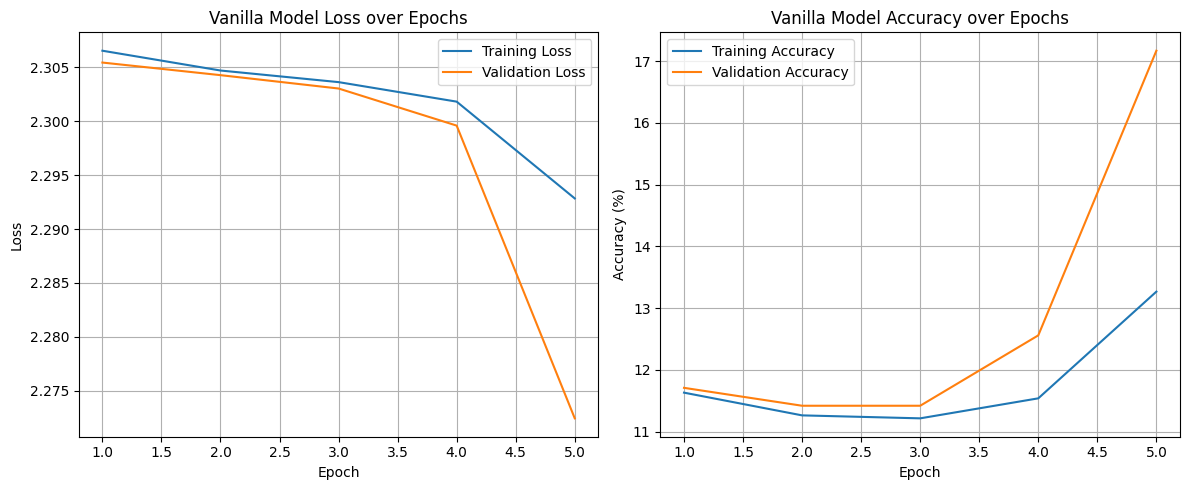


--- Evaluation for Vanilla Model ---
Accuracy: 0.1718
Precision: 0.1726
Recall: 0.1629
F1 Score: 0.1012


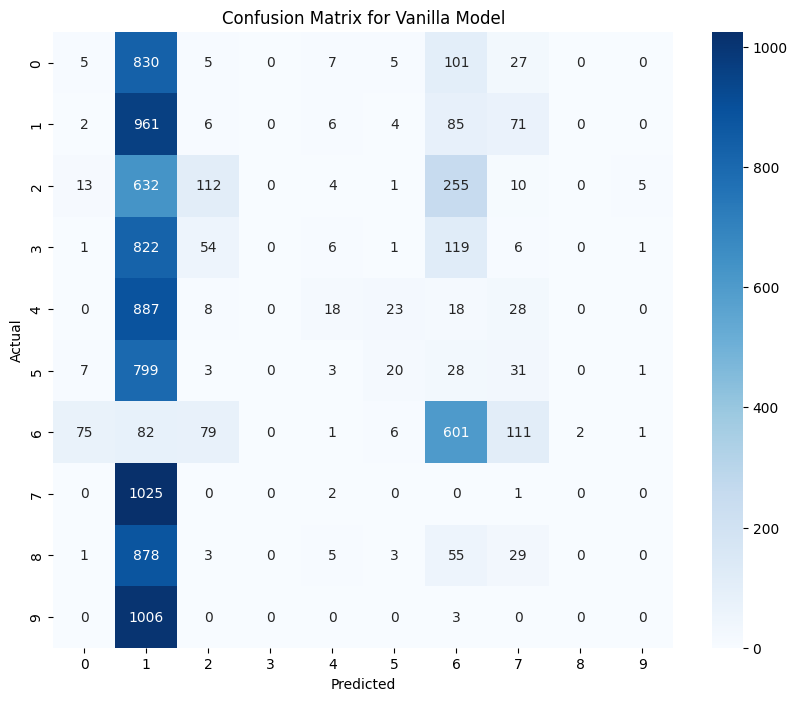

In [8]:
# Helper function to evaluate the vanilla model and collect predictions
def get_vanilla_predictions(kernel_conv, weight, bias, data_loader, num_classes, device):
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            batch_outputs = []
            for image in batch_images:
                input_data = torch.squeeze(image)
                out_conv = conv2d(input_data, kernel_conv, stride_conv, dilation_conv, device)
                out_relu = func_relu(out_conv)
                out_pooling = max_pool(out_relu, pool_size, stride_pool)
                out_flatten = out_pooling.reshape(-1, 1)
                out_fc = fully_connected(out_flatten, weight, bias, num_classes, device)
                batch_outputs.append(out_fc)

            # Stack outputs for batch processing
            if len(batch_outputs) > 0:
                stacked_outputs = torch.stack(batch_outputs, dim=0)
                _, predicted = torch.max(stacked_outputs.data, 1)
                all_labels.extend(batch_labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
    return all_labels, all_predictions

# Helper function to plot loss and accuracy curves for vanilla model
def plot_vanilla_loss_curves(train_losses, val_losses, train_accuracies, val_accuracies, model_name="Vanilla Model"):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title(f'{model_name} Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Device configuration
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Inisialisasi learning rate dan jumlah iterasi
lr = 0.1
num_epochs = 5 # Use a smaller number of epochs for vanilla to avoid very long runtimes
# Melakukan inisialisasi dari beberapa parameter convolution+pooling layer
kernel_conv = torch.randn((5, 5), dtype=torch.float).to(device).requires_grad_(True)
stride_conv = (2, 2)
dilation_conv = (1, 1)
pool_size = (2, 2)
stride_pool = (2, 2)

# Processes to check the output size of conv+pooling
with torch.no_grad():
  for batch in train_loader:
    output = []
    images, labels = batch
    images = images.to(device)
    for image in images:
      input_data = torch.squeeze(image)
      # print(f"Ukuran input_data = ", input_data.shape) # Commented out for cleaner output
      out_conv = conv2d(input_data, kernel_conv, stride_conv, dilation_conv, device)
      # print(f"Ukuran luaran dari Conv = ", out_conv.shape) # Commented out for cleaner output
      out_pooling = max_pool(out_conv, pool_size, stride_pool)
      # print(f"Ukuran luaran dari Pooling = ", out_pooling.shape) # Commented out for cleaner output
      out_flatten = out_pooling.reshape(-1, 1)
      # print(f"Ukuran luaran dari Flatten = ", out_flatten.shape) # Commented out for cleaner output
      break
    break
# Melakukan inisialisasi dari beberapa parameter untuk fully connected layer
out_convPool_size = out_pooling.shape
out_before_flatten = out_convPool_size[0] * out_convPool_size[1]
weight = torch.randn((out_before_flatten, num_classes), dtype=torch.float).to(device).requires_grad_(True)
bias = torch.randn((1, num_classes), dtype=torch.float).to(device).requires_grad_(True)

# Training process
loss_train_history = []
loss_val_history = []
train_accuracies = [] # Store train accuracy per epoch
val_accuracies = []   # Store validation accuracy per epoch

print(f"\n--- Training Vanilla Model ---")
for epoch in range(num_epochs):
  print(f"Epoch = {epoch+1}")

  running_loss_train = 0.0
  correct_train = 0
  total_train = 0

  nomor_batch = 1
  for batch_images, batch_labels in train_loader:
    batch_images = batch_images.to(device)
    batch_labels = batch_labels.to(device)

    batch_outputs = []
    for image_idx in range(len(batch_images)): # Iterate over images in the batch
        image = batch_images[image_idx]
        label = batch_labels[image_idx]

        input_data = torch.squeeze(image)
        out_conv = conv2d(input_data, kernel_conv, stride_conv, dilation_conv, device)
        out_relu = func_relu(out_conv)
        out_pooling = max_pool(out_relu, pool_size, stride_pool)
        out_flatten = out_pooling.reshape(-1, 1)
        out_fc = fully_connected(out_flatten, weight, bias, num_classes, device)
        batch_outputs.append(out_fc)

    # After processing all images in the batch
    if len(batch_outputs) > 0:
        stacked_outputs = torch.stack(batch_outputs, dim=0) # Stack outputs from current batch
        loss = loss_crossEntropy(stacked_outputs, batch_labels, num_classes, device)

        # Backward and optimize
        loss.backward()
        with torch.no_grad():
          sgd([weight, bias], lr, len(batch_images)) # num_data should be len(batch_images)
          sgd([kernel_conv], lr, len(batch_images))

        # Zero gradients after update
        weight.grad.zero_()
        bias.grad.zero_()
        kernel_conv.grad.zero_()

        running_loss_train += loss.item()
        _, predicted = torch.max(stacked_outputs.data, 1)
        total_train += batch_labels.size(0)
        correct_train += (predicted == batch_labels).sum().item()

    print(f"Loss dari batch ke-{nomor_batch}/{len(train_loader)} = {loss:.4f}")
    nomor_batch += 1

  # End of epoch calculations for training
  train_loss_epoch = running_loss_train / len(train_loader)
  train_acc_epoch = 100 * correct_train / total_train
  loss_train_history.append(train_loss_epoch)
  train_accuracies.append(train_acc_epoch)

  # Validation phase (single pass over entire validation set)
  val_labels, val_predictions = get_vanilla_predictions(kernel_conv, weight, bias, val_loader, num_classes, device)
  val_acc_epoch = 100 * accuracy_score(val_labels, val_predictions) # Using sklearn's accuracy_score
  val_accuracies.append(val_acc_epoch)

  # Calculate validation loss for plotting
  running_loss_val = 0.0
  with torch.no_grad():
    for batch_images, batch_labels in val_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        batch_outputs = []
        for image in batch_images:
            input_data = torch.squeeze(image)
            out_conv = conv2d(input_data, kernel_conv, stride_conv, dilation_conv, device)
            out_relu = func_relu(out_conv)
            out_pooling = max_pool(out_relu, pool_size, stride_pool)
            out_flatten = out_pooling.reshape(-1, 1)
            out_fc = fully_connected(out_flatten, weight, bias, num_classes, device)
            batch_outputs.append(out_fc)

        if len(batch_outputs) > 0:
            stacked_outputs = torch.stack(batch_outputs, dim=0)
            loss_val = loss_crossEntropy(stacked_outputs, batch_labels, num_classes, device)
            running_loss_val += loss_val.item()
  val_loss_epoch = running_loss_val / len(val_loader) if len(val_loader) > 0 else 0
  loss_val_history.append(val_loss_epoch)

  print(f'Epoch [{epoch+1}/{num_epochs}], ' \
        f'Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.2f}%, ' \
        f'Val Loss: {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.2f}%')
print(f"--- Training of Vanilla Model finished ---")

# Plot loss and accuracy curves
plot_vanilla_loss_curves(loss_train_history, loss_val_history, train_accuracies, val_accuracies, model_name="Vanilla Model")

# Evaluate Vanilla model on test set
print(f"\n--- Evaluation for Vanilla Model ---")
test_labels, test_predictions = get_vanilla_predictions(kernel_conv, weight, bias, test_loader, num_classes, device)

accuracy = accuracy_score(test_labels, test_predictions)
precision = precision_score(test_labels, test_predictions, average='macro', zero_division=0)
recall = recall_score(test_labels, test_predictions, average='macro', zero_division=0)
f1 = f1_score(test_labels, test_predictions, average='macro', zero_division=0)
cm = confusion_matrix(test_labels, test_predictions)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for Vanilla Model')
plt.show()

## Waktu Training :

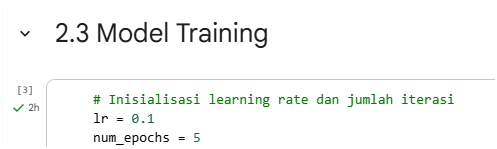